In [1]:
import matplotlib
import matplotlib.pyplot as plt
#from collections import OrderedDict
import seaborn as sns

import numpy as np
import os
import scipy
import pickle

from neurolib.models.aln import ALNModel
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc

# a nice color map
#sns.set()
#cmap = plt.get_cmap('plasma')
plt.rcParams['image.cmap'] = 'plasma'
cpalette = sns.color_palette('plasma')
np.set_printoptions(precision=4)

#matplotlib.style.use('classic')

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 14
       }

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=16) 
matplotlib.rc('ytick', labelsize=16) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
matplotlib.rc('savefig', dpi=300)       # higher res outputs
#print (matplotlib.rcParams)
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

path = os.path.join(os.getcwd(), "plots")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Bistability

In [2]:
aln = ALNModel()
N = aln.params.N

aln.params.mufe_init = 0 * np.random.uniform(0, 1, (N,))  # mV/ms
aln.params.mufi_init = 0 * np.random.uniform(0, 1, (N,))  # mV/ms
aln.params.seem_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.seim_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.seev_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.seiv_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.siim_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.siem_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.siiv_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.siev_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.rates_exc_init = 0.0 * np.random.uniform(0, 1, (N, 1))
aln.params.rates_inh_init = 0.0 * np.random.uniform(0, 1, (N, 1))
aln.params.IA_init = 0.0 * np.random.uniform(0, 1, (N, 1))  # pA

aln.params.sigma_ou = 0.
aln.params.mue_ou = np.array( [0.] )
aln.params.mui_ou = np.array( [0.] )

state_vars = aln.state_vars
init_vars = aln.init_vars

def step_control(maxI_ = 1.):
    control_ = aln.getZeroControl()
    for i_time in range(control_.shape[2]):
        if ( float(i_time/control_.shape[2]) < 0.1):
            control_[:,:1,i_time] = - maxI_
        elif ( float(i_time/control_.shape[2]) > 0.5 and float(i_time/control_.shape[2]) < 0.6 ):
            control_[:,:1,i_time] = maxI_
    return control_

def setinit(init_vars_):
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if aln.params[init_vars[iv]].ndim == 2:
                    aln.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    aln.params[init_vars[iv]][0] = init_vars_[sv]

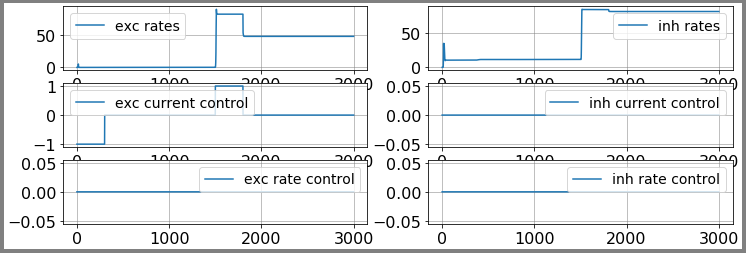

[[47.5098 82.4113]
 [ 0.0825 11.6383]]


In [3]:
aln.params['duration'] = 3000.

control0 = aln.getZeroControl()
target = aln.getZeroTarget()
control0 = step_control(maxI_ = 1.)

aln.params.ext_exc_current = 2.5
aln.params.ext_inh_current = 2.

aln.params.mue_ext_mean = 0.
aln.params.mui_ext_mean = 0.

aln.params.sigmae_ext = 0.5
aln.params.sigmai_ext = 0.5

# NO ADAPTATION
aln.params.a = 0.
aln.params.b = 0.

plotFunc.plot_traces(aln, control0)
    
steady_rates = np.zeros((2, 2))
steady_rates[0,0] = aln.rates_exc[0,-1] # high state exc
steady_rates[0,1] = aln.rates_inh[0,-1] # high state inh
steady_rates[1,0] = aln.rates_exc[0,14500] # low state exc
steady_rates[1,1] = aln.rates_inh[0,14500] # low state inh

print(steady_rates)

high_state_vars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    #print("final value of state var ", aln.state_vars[i], " : ", aln.state[state_vars[i]])
    if aln.state[state_vars[i]].size == 1:
        high_state_vars[i] = aln.state[state_vars[i]][0] 
    else:
        high_state_vars[i] = aln.state[state_vars[i]][0,-1]

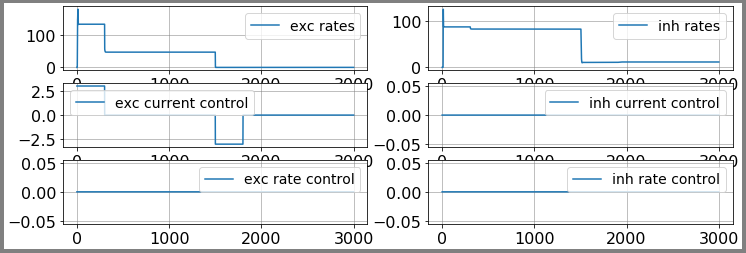

low state vars =  [ 8.2469e-02  1.1638e+01  4.3314e-01  7.5957e-01  0.0000e+00  1.6029e-02
  6.3812e-01  1.4997e-02  7.8014e-01  9.5893e-04  6.6523e-03  8.4016e-04
  6.5247e-03  0.0000e+00  0.0000e+00  7.1463e-01  5.5403e-01 -5.6298e+01
  2.7100e+01  6.3823e+00]


In [4]:
control0 = step_control(maxI_ = -3.)
plotFunc.plot_traces(aln, control0)

low_state_vars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    #print("final value of state var ", aln.state_vars[i], " : ", aln.state[state_vars[i]])
    if aln.state[state_vars[i]].size == 1:
        low_state_vars[i] = aln.state[state_vars[i]][0]
    else:
        low_state_vars[i] = aln.state[state_vars[i]][0,-1]

print("low state vars = ", low_state_vars)

# A: Scenarios

scenario | control variables | precision measure
---------|--------------|-----------
A.0 | 0 | 0
B.1 | 1 | 1
B.2 | 2 | 0
B.3 | 0 | 1
B.4 | 1 | 0
B.5 | 2 | 1
B.6 | 0, 1 | 0
B.7 | 0, 1 | 1
B.8 | 0, 2 | 0
B.9 | 0, 2 | 1
B.10 | 1, 2 | 0
B.11 | 1, 2 | 1
B.12 | 0, 1, 2 | 0
B.13 | 0, 1, 2 | 1
B.14 | 0 | 0,1
B.15 | 1 | 0,1
B.16 | 2 | 0,1
B.17 | 0,1 | 0,1
B.18 | 0,2 | 0,1
B.19 | 1,2 | 0,1
B.20 | 0,1,2 | 0,1

In [5]:
c_var = [ [0], [1], [2], [0], [1], [2],
         [0,1], [0,1], [0,2], [0,2], [1,2], [1,2],
         [0,1,2], [0,1,2],
         [0], [1], [2], [0,1], [0,2], [1,2], [0,1,2] ]
p_var = [ [0], [1], [0], [1], [0], [1],
         [0], [1], [0], [1], [0], [1],
         [0], [1],
         [0,1], [0,1], [0,1], [0,1], [0,1], [0,1], [0,1] ]

max_it = 5000

initVars = high_state_vars

tol = 1e-32
start_step = 10.
c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

trans_time_array = [0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 
                    0.8, 0.8, 0.8, 0.8, 0.8 ]

sheet = "B"

target_rates = np.array( [steady_rates[1,0], steady_rates[1,1]])

In [6]:
max_c_c = 5.
min_c_c = - 5.
max_c_r = 0.18
min_c_r = 0.

def setmaxmincontrol(cntrl_vars):
    max_cntrl = np.zeros(( 4 ))
    min_cntrl = np.zeros(( 4 ))
    if cntrl_vars == [0]:
        max_cntrl[0] = max_c_c
        min_cntrl[0] = min_c_c
    elif cntrl_vars == [1]:
        max_cntrl[1] = max_c_c
        min_cntrl[1] = min_c_c
    elif cntrl_vars == [2]:
        max_cntrl[2] = max_c_r
        min_cntrl[2] = min_c_r
    elif cntrl_vars == [0,1]:
        max_cntrl[0] = max_c_c
        min_cntrl[0] = min_c_c
        max_cntrl[1] = max_c_c
        min_cntrl[1] = min_c_c
    elif cntrl_vars == [0,2]:
        max_cntrl[0] = max_c_c
        min_cntrl[0] = min_c_c
        max_cntrl[2] = max_c_r
        min_cntrl[2] = min_c_r
    elif cntrl_vars == [1,2]:
        max_cntrl[1] = max_c_c
        min_cntrl[1] = min_c_c
        max_cntrl[2] = max_c_r
        min_cntrl[2] = min_c_r
    elif cntrl_vars == [0,1,2]:
        max_cntrl[0] = max_c_c
        min_cntrl[0] = min_c_c
        max_cntrl[1] = max_c_c
        min_cntrl[1] = min_c_c
        max_cntrl[2] = max_c_r
        min_cntrl[2] = min_c_r
            
    return max_cntrl, min_cntrl        

## 0

set cost params
control input:  [0] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
RUN  1 , total integrated cost =  0.0672296612782888
RUN  2 , total integrated cost =  0.06677027392124696
RUN  3 , total integrated cost =  0.06654833012979747
RUN  4 , total integrated cost =  0.06649985815064706
RUN  5 , total integrated cost =  0.06622123786670793
RUN  6 , total integrated cost =  0.06606499385567977
RUN  7 , total integrated cost =  0.06552273878245031
RUN  8 , total integrated cost =  0.06538350073924677
RUN  9 , total integrated cost =  0.06518109534923736
RUN  10 , total integrated cost =  0.06505411905578283
RUN  11 , total integrated cost =  0.06499223814050852
RUN  12 , total integrated cost =  0.06494536887158549
RUN  13 , total integrated cost =  0.06490782829609279
RUN  14 , total integrated cost =  0.06488268950320784
RUN  15 , total integrated cost =  0.06485448906388822
RUN  16 , total integrated cost 

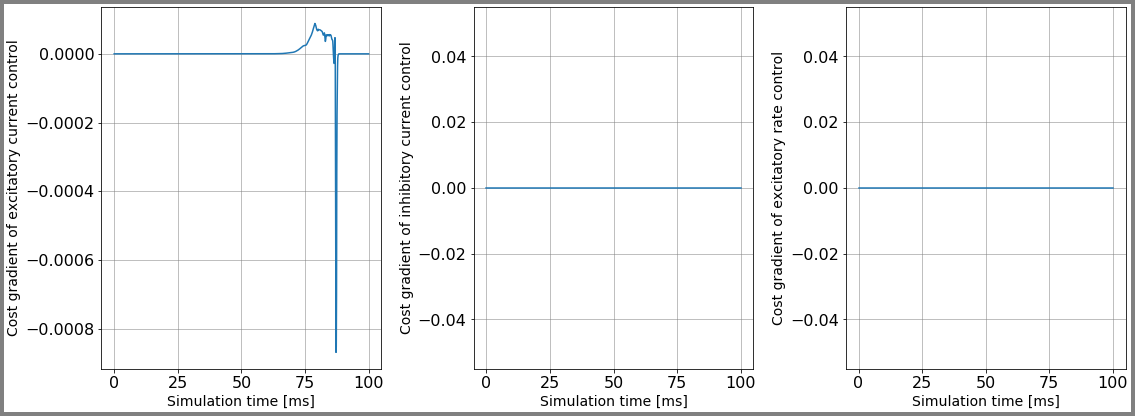

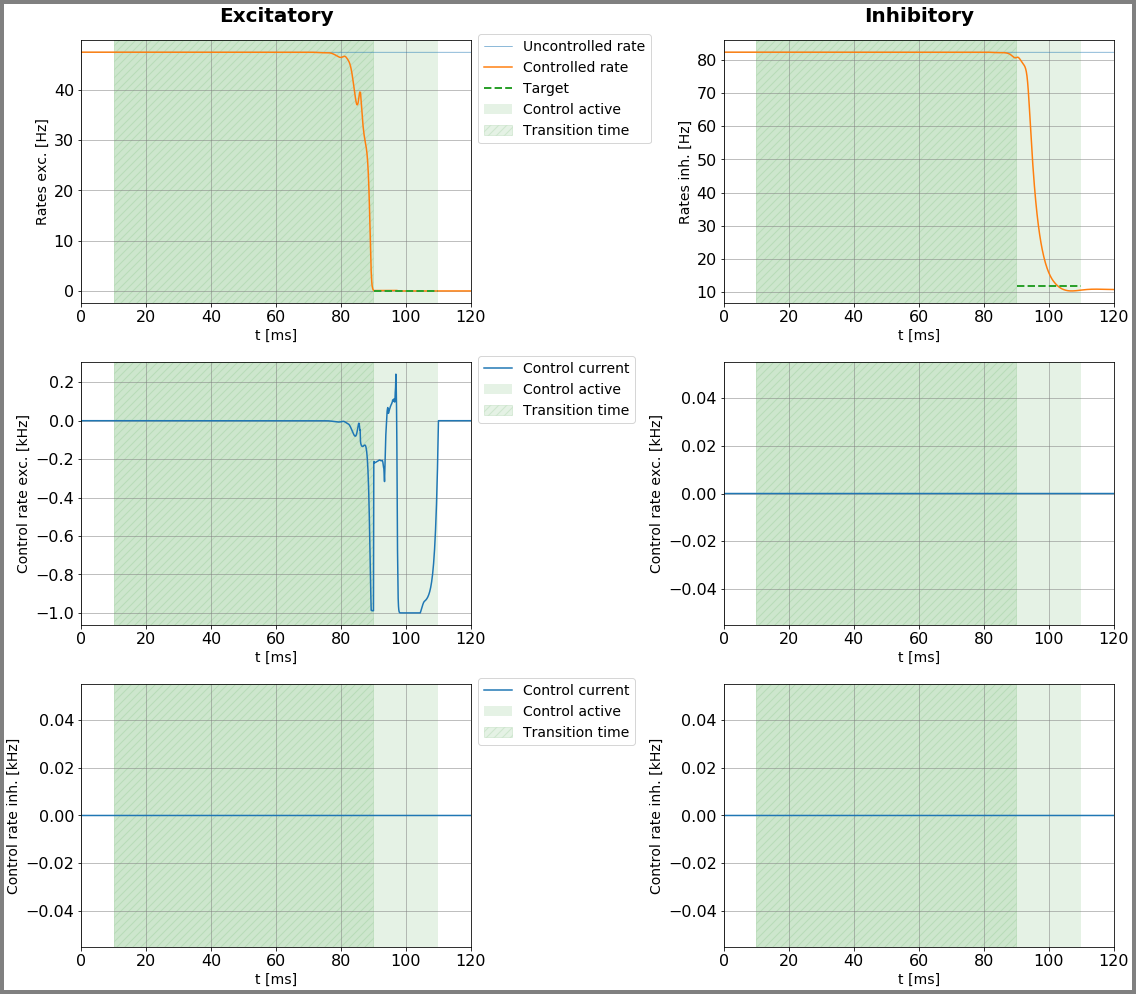

In [7]:
# B.0.a)

dur = 100
dur_pre = 10
dur_post = 10
aln.params.duration = dur

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

# set low state rates as target
target = aln.getZeroTarget()
target[:,0,:] = target_rates[0]
target[:,1,:] = target_rates[1]

case_ind = 0
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

set cost params
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
RUN  1 , total integrated cost =  973.1494953914903
RUN  2 , total integrated cost =  723.7835266402074
RUN  3 , total integrated cost =  505.6419230191318
RUN  4 , total integrated cost =  450.66162414833434
RUN  5 , total integrated cost =  394.1221705582965
RUN  6 , total integrated cost =  371.44744577860035
RUN  7 , total integrated cost =  351.69352081768744
RUN  8 , total integrated cost =  341.1141172895118
RUN  9 , total integrated cost =  332.2077359764999
RUN  10 , total integrated cost =  326.70378610383216
RUN  11 , total integrated cost =  321.4449207744851
RUN  12 , total integrated cost =  318.0532952837113
RUN  13 , total integrated cost =  314.3555010291499
RUN  14 , total integrated cost =  312.19631432253806
RUN  15 , total integrated cost =  309.40676860740507
RUN  16 , total integrated cost =  307.5112010333213
RUN  17 , total integrated cost =  305.452471691

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  1197 , total integrated cost =  231.8191673924916
Improved over  1197  iterations by  98.96939460065327  percent.
Problem in initial value trasfer:  Vmean_exc -57.15494658346237 -57.15274376866155


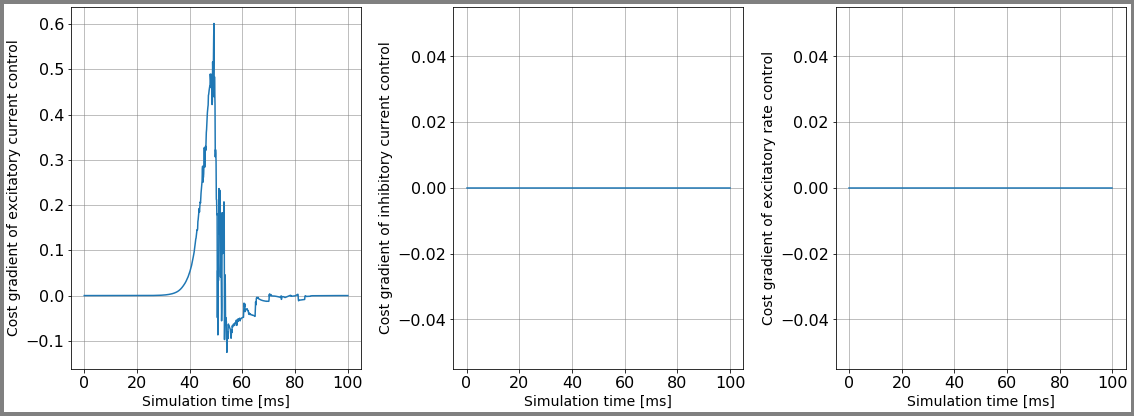

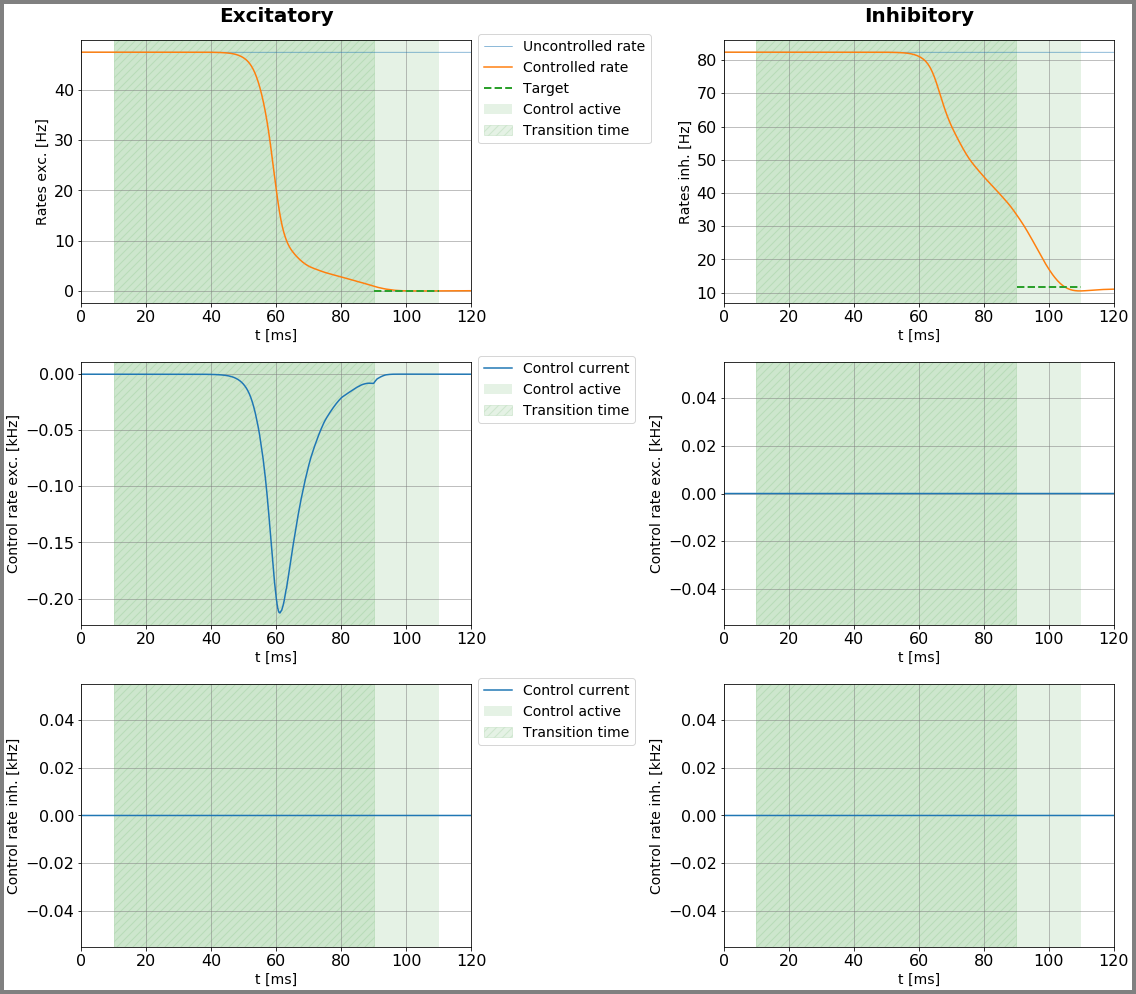

In [8]:
# A.0.b) high => low, exc current max 1nA, precision + energy + sparsity
case_ind = 0
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 30.0)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
    transition_time_ = trans_time ) #separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

## 2

set cost params
control input:  [2] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
RUN  1 , total integrated cost =  22493.494361608944
Control only changes marginally.
RUN  1 , total integrated cost =  22493.494361608944
Improved over  1  iterations by  0.0  percent.


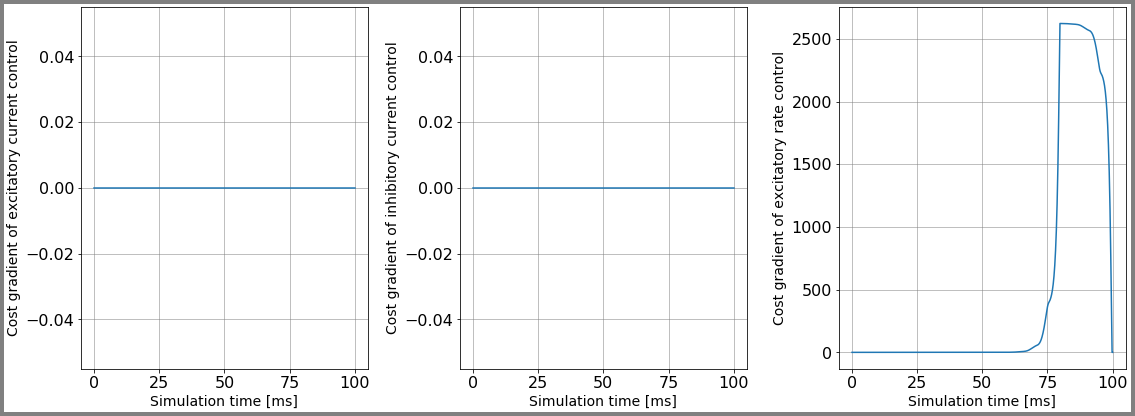

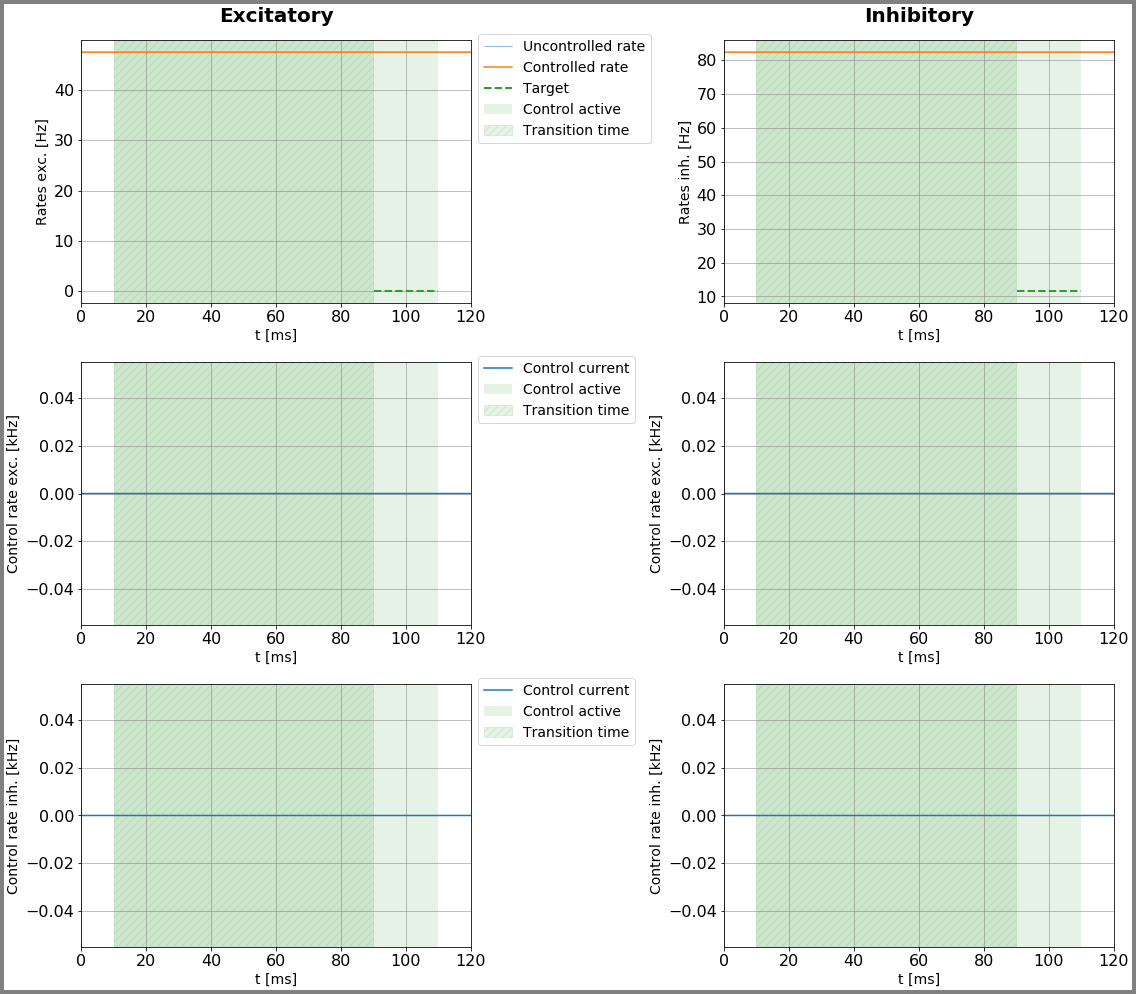

In [9]:
case_ind = 2
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

set cost params
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
RUN  1 , total integrated cost =  22493.494361608944
Control only changes marginally.
RUN  1 , total integrated cost =  22493.494361608944
Improved over  1  iterations by  0.0  percent.


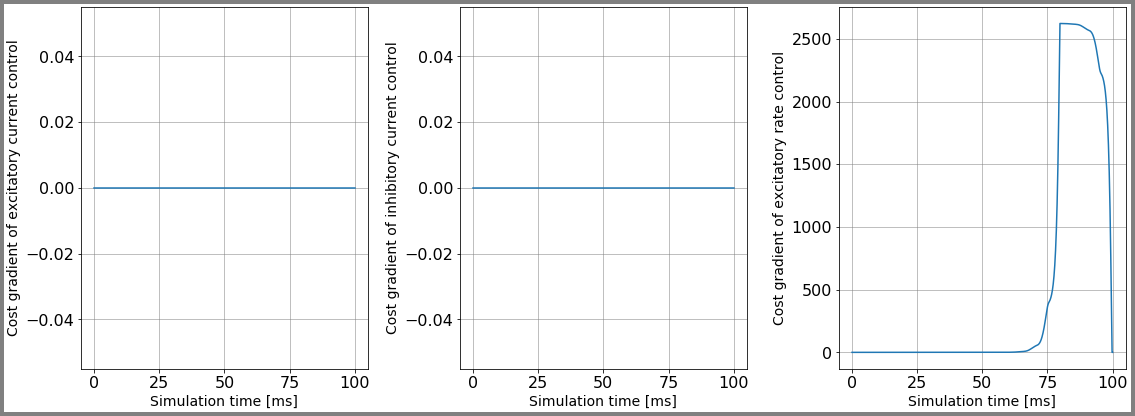

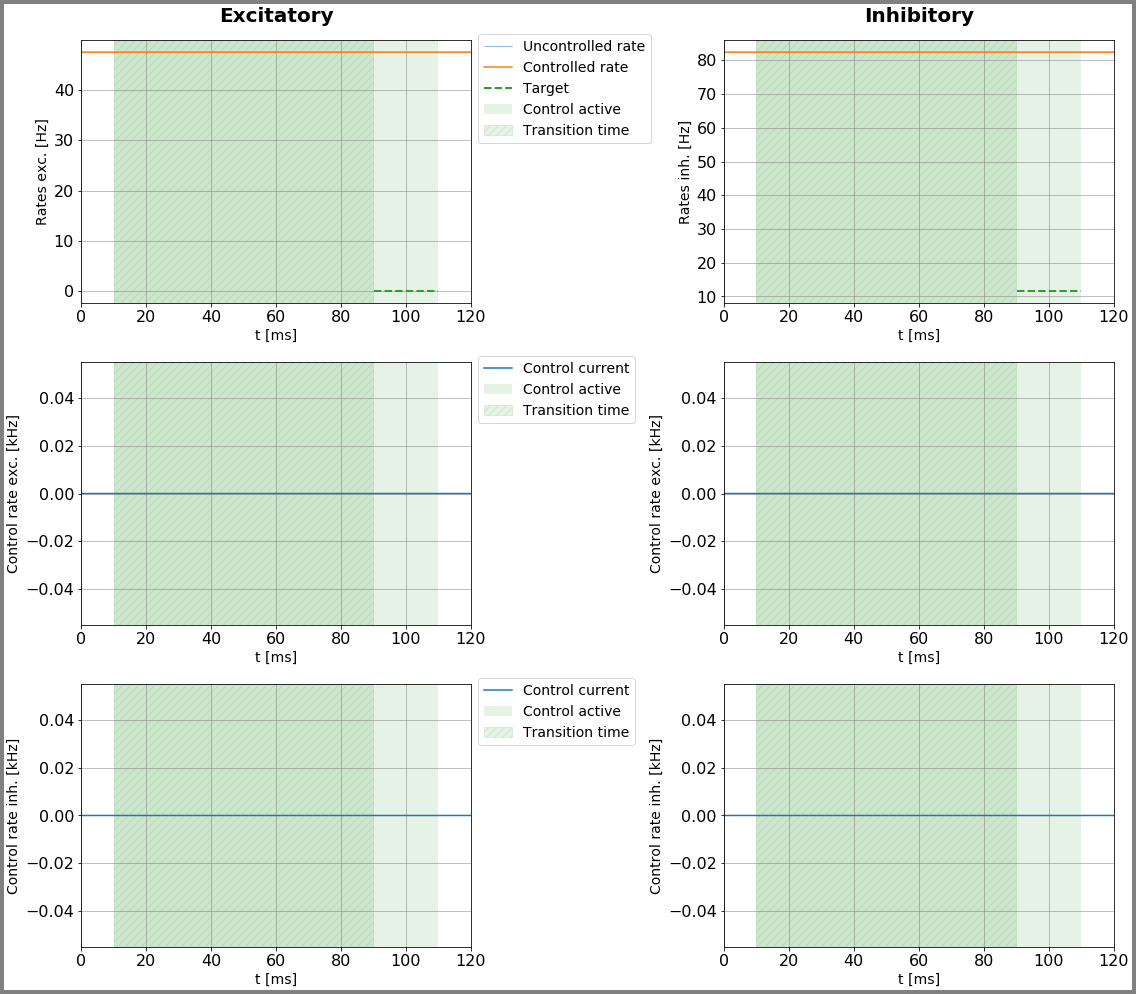

In [10]:
case_ind = 2
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 30.0)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
    transition_time_ = trans_time ) #separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

## 4

set cost params
control input:  [1] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
RUN  1 , total integrated cost =  17645.071903884807
RUN  2 , total integrated cost =  17645.071611564603
RUN  3 , total integrated cost =  17645.07159126802
RUN  4 , total integrated cost =  17645.071591170505
RUN  5 , total integrated cost =  17645.07159116955
RUN  6 , total integrated cost =  17645.071591169522
RUN  7 , total integrated cost =  17645.071591169522


ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  7 , total integrated cost =  17645.071591169522
Improved over  7  iterations by  21.5547779837824  percent.
Problem in initial value trasfer:  Vmean_exc -56.08376323731158 -56.086770296524435


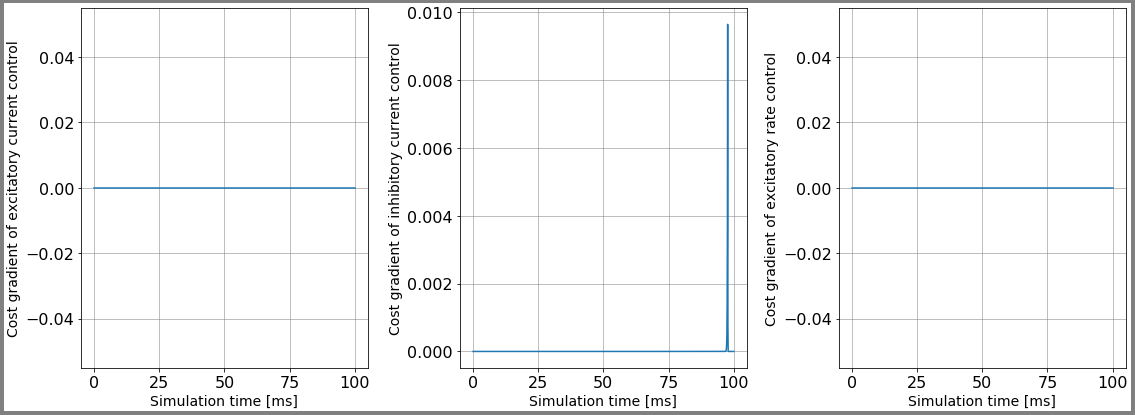

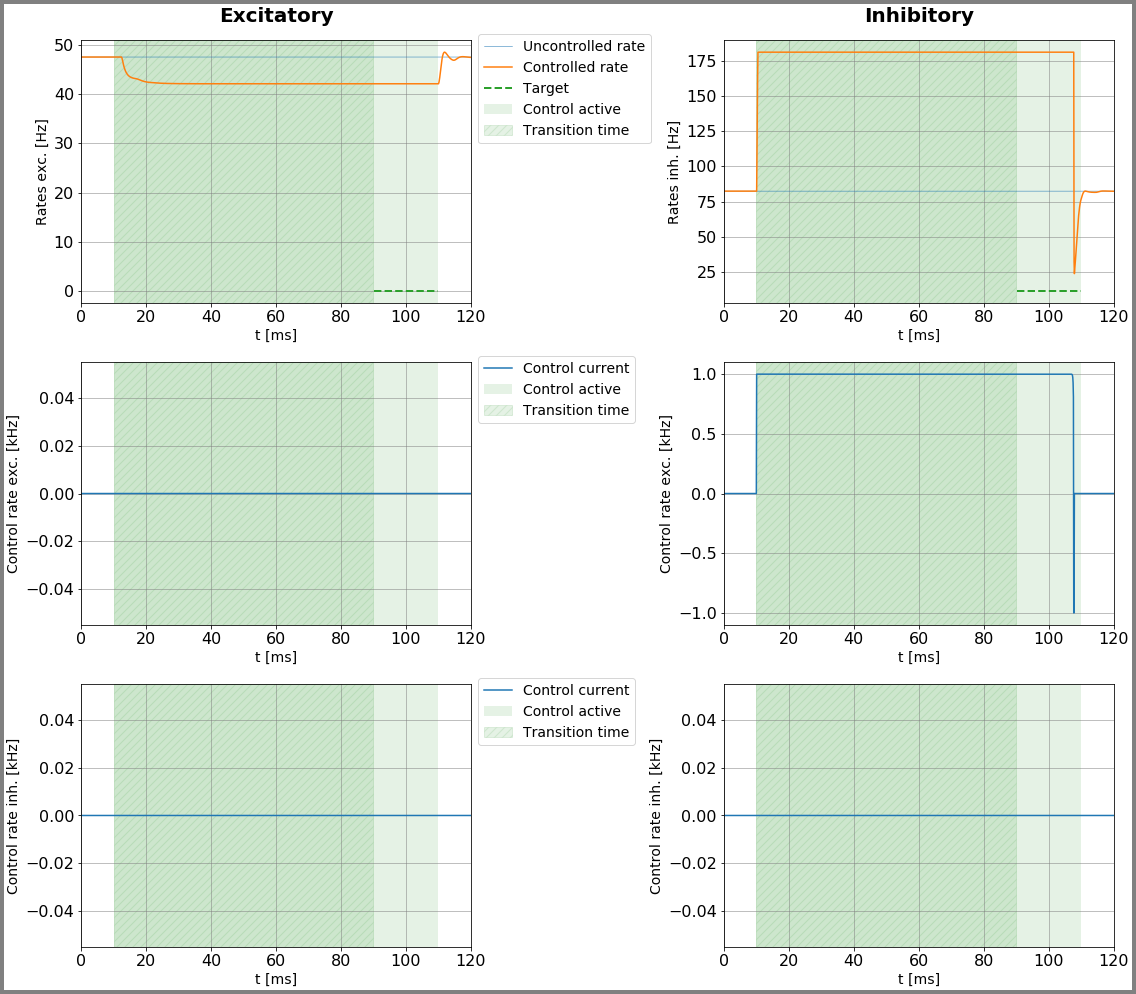

In [11]:
# A.4.a)

case_ind = 4
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

set cost params
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
RUN  1 , total integrated cost =  20713.97859171807
RUN  2 , total integrated cost =  20701.050679324457
RUN  3 , total integrated cost =  20700.7943291295
RUN  4 , total integrated cost =  20700.757542450257
RUN  5 , total integrated cost =  20700.749812818056
RUN  6 , total integrated cost =  20700.742311478356
RUN  7 , total integrated cost =  20700.73844357013
RUN  8 , total integrated cost =  20700.738374051147
RUN  9 , total integrated cost =  20700.737890955934
RUN  10 , total integrated cost =  20700.73655393961
RUN  11 , total integrated cost =  20700.736217142225
RUN  12 , total integrated cost =  20700.7356714599
RUN  13 , total integrated cost =  20700.735610154323
RUN  14 , total integrated cost =  20700.735378946294
RUN  15 , total integrated cost =  20700.735146926905
RUN  16 , total integrated cost =  20700.735095621214
RUN  17 , total integrated cost =  20700.7349

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  24 , total integrated cost =  20700.73435700526
Improved over  24  iterations by  7.970126721010942  percent.
Problem in initial value trasfer:  Vmean_exc -56.13984838129106 -56.141369803786674


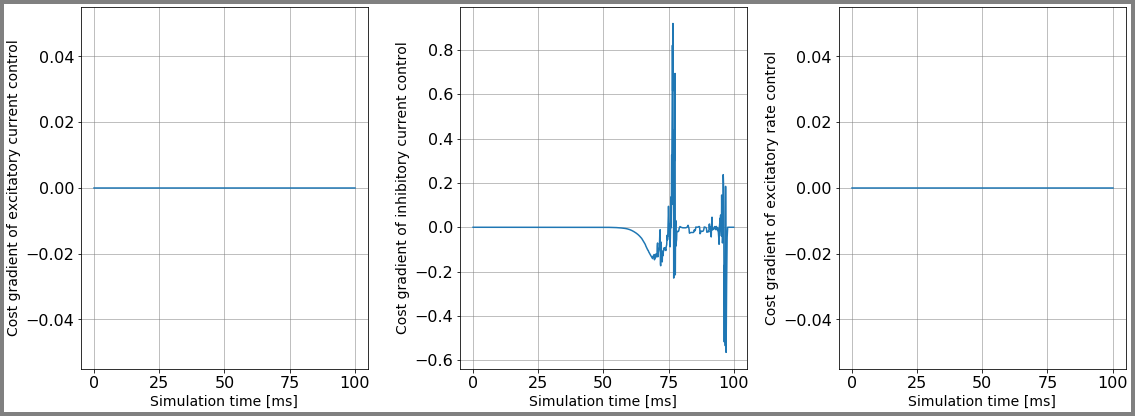

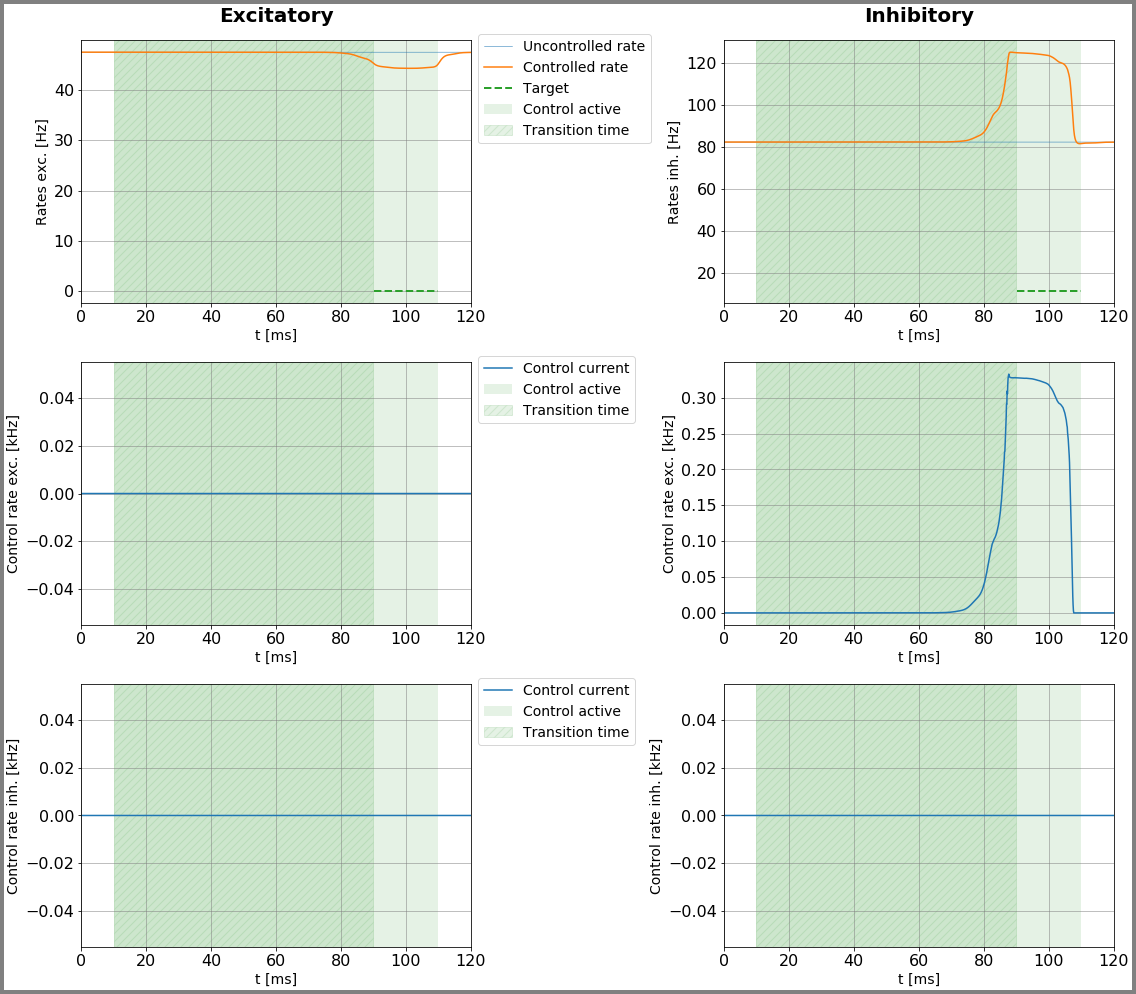

In [12]:
case_ind = 4
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 30.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
    transition_time_ = trans_time ) #separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

## 6

set cost params
control input:  [0, 1] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
RUN  1 , total integrated cost =  0.06696649211560546
RUN  2 , total integrated cost =  0.06679908282036125
RUN  3 , total integrated cost =  0.06564051269592165
RUN  4 , total integrated cost =  0.06483163857458686
RUN  5 , total integrated cost =  0.06469967972185202
RUN  6 , total integrated cost =  0.06463035152962483
RUN  7 , total integrated cost =  0.0645864741066015
RUN  8 , total integrated cost =  0.06451119147290216
RUN  9 , total integrated cost =  0.06443986757534513
RUN  10 , total integrated cost =  0.06414234885161232
RUN  11 , total integrated cost =  0.06385225761778789
RUN  12 , total integrated cost =  0.06342643347044195
RUN  13 , total integrated cost =  0.06286860115771487
RUN  14 , total integrated cost =  0.06280624563883988
RUN  15 , total integrated cost =  0.06276203306914914
RUN  16 , total integrated co

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  4173 , total integrated cost =  0.021938162095943955
Improved over  4173  iterations by  99.99990246885724  percent.
Problem in initial value trasfer:  Vmean_exc -78.85724439220117 -78.84947647022146


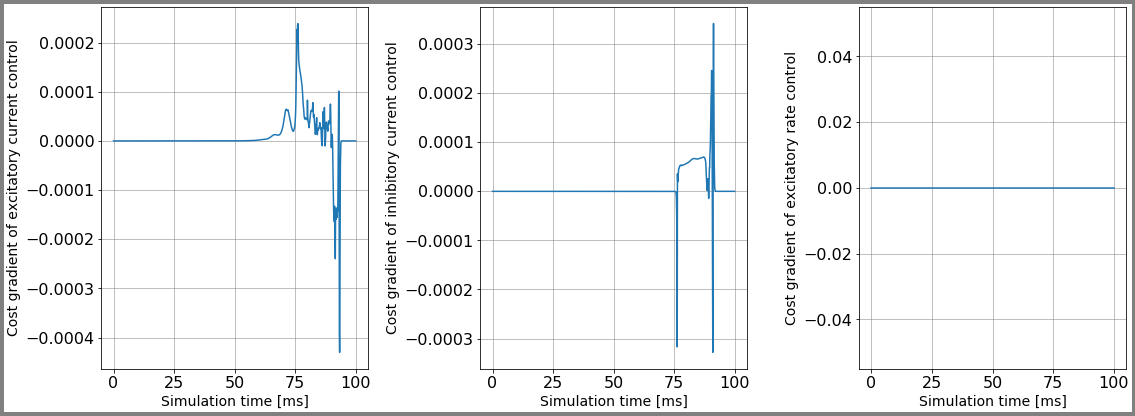

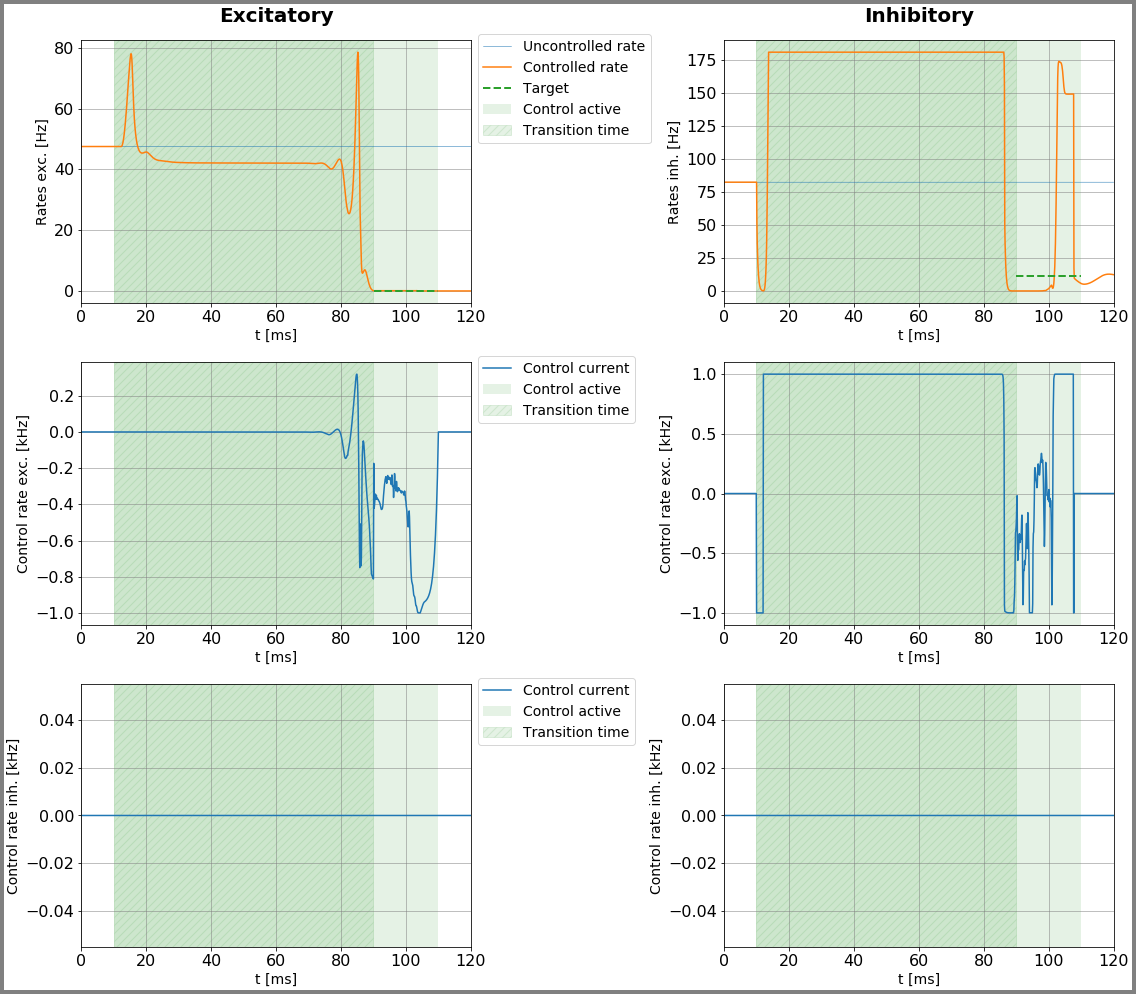

In [13]:
# A.6.a)
case_ind = 6
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

set cost params
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
RUN  1 , total integrated cost =  973.1494953914903
RUN  2 , total integrated cost =  723.7835266402074
RUN  3 , total integrated cost =  505.6419230191318
RUN  4 , total integrated cost =  450.66162414833434
RUN  5 , total integrated cost =  394.1221705582965
RUN  6 , total integrated cost =  371.44744577860035
RUN  7 , total integrated cost =  351.69352081768744
RUN  8 , total integrated cost =  341.1141172895118
RUN  9 , total integrated cost =  332.2077359764999
RUN  10 , total integrated cost =  326.70378610383216
RUN  11 , total integrated cost =  321.4449207744851
RUN  12 , total integrated cost =  318.0532952837113
RUN  13 , total integrated cost =  314.3555010291499
RUN  14 , total integrated cost =  312.19631432253806
RUN  15 , total integrated cost =  309.40676860740507
RUN  16 , total integrated cost =  307.5112010333213
RUN  17 , total integrated cost =  305.452471691

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  1251 , total integrated cost =  231.49834550149313
Improved over  1251  iterations by  98.97082088812041  percent.
Problem in initial value trasfer:  Vmean_exc -57.14913782297948 -57.14662364164482


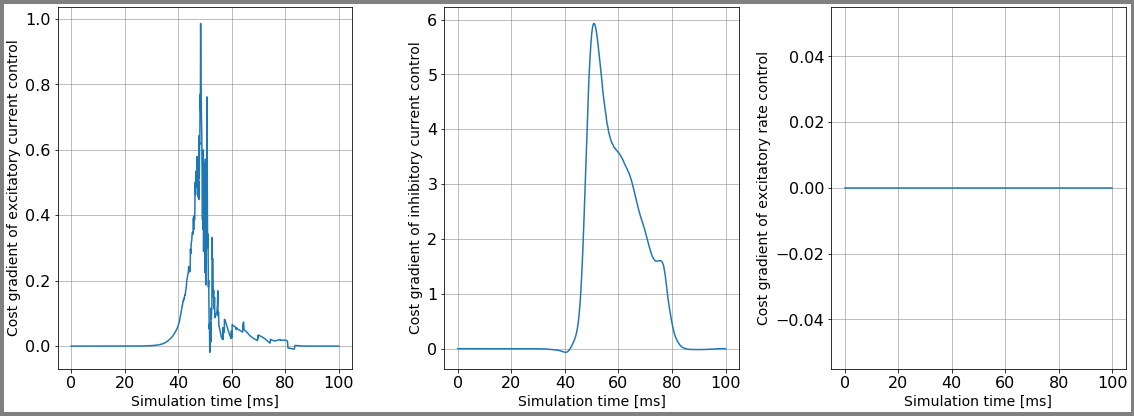

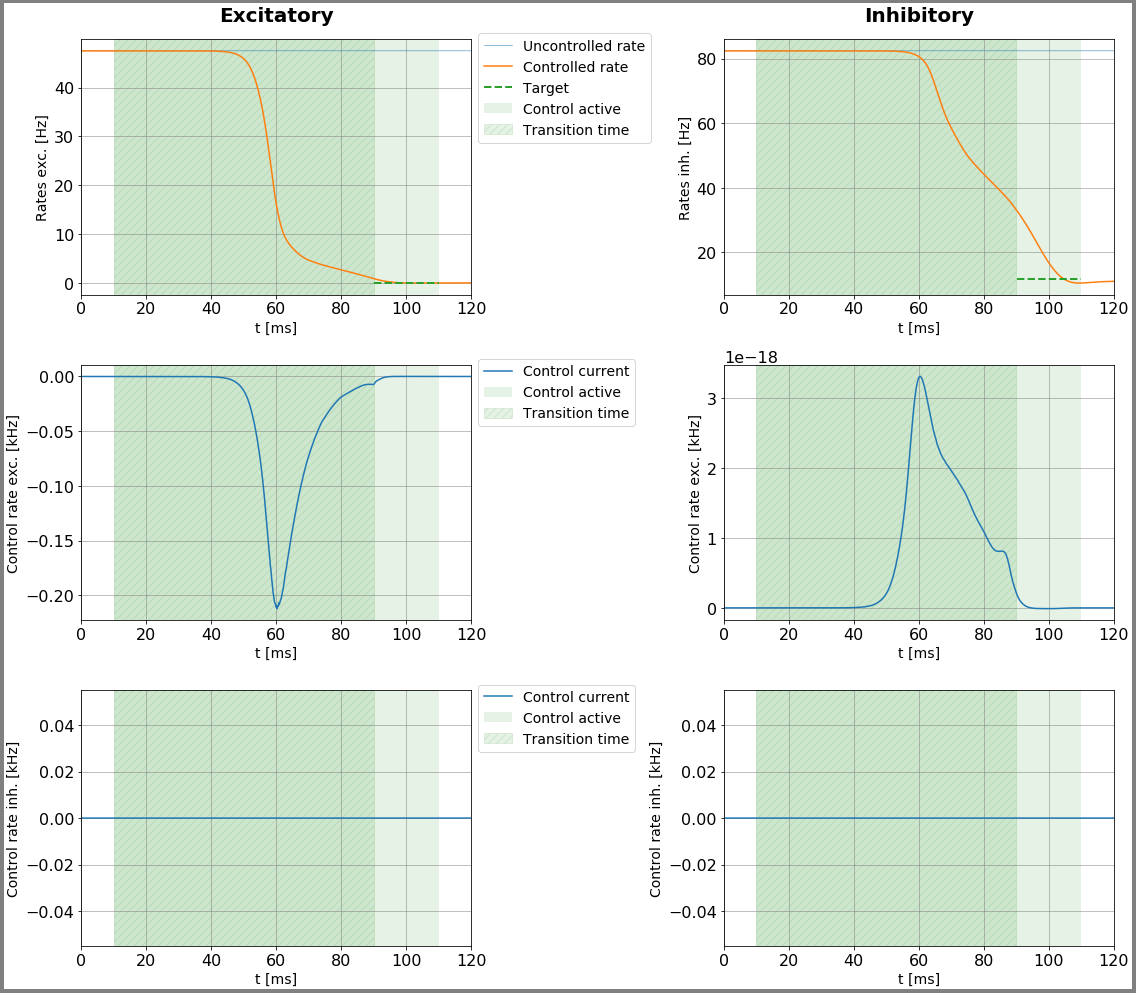

In [14]:
case_ind = 6
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 30.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
    transition_time_ = trans_time ) #separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

## 8

set cost params
control input:  [0, 2] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
RUN  1 , total integrated cost =  0.0672296612782888
RUN  2 , total integrated cost =  0.06675176193206525
RUN  3 , total integrated cost =  0.06648151287297004
RUN  4 , total integrated cost =  0.0663509971720387
RUN  5 , total integrated cost =  0.06627931645109507
RUN  6 , total integrated cost =  0.06624016003621275
RUN  7 , total integrated cost =  0.06617886524181996
RUN  8 , total integrated cost =  0.06614483418156865
RUN  9 , total integrated cost =  0.06610064714029738
RUN  10 , total integrated cost =  0.06606047677593843
RUN  11 , total integrated cost =  0.06599156928290587
RUN  12 , total integrated cost =  0.06594182704885349
RUN  13 , total integrated cost =  0.06588387158821325
RUN  14 , total integrated cost =  0.06582904847115024
RUN  15 , total integrated cost =  0.06577527719444498
RUN  16 , total integrated cos

ERROR:root:Problem in initial value trasfer


RUN  5000 , total integrated cost =  0.02506531680454135
RUN  5000 , total integrated cost =  0.02506531680454135
Improved over  5000  iterations by  99.99988856637212  percent.
Problem in initial value trasfer:  Vmean_exc -75.37308329842101 -75.29862143313625


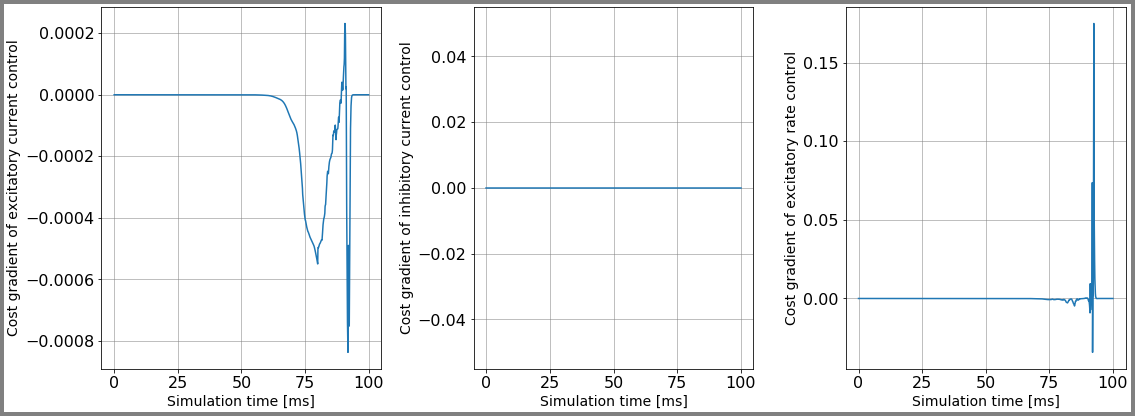

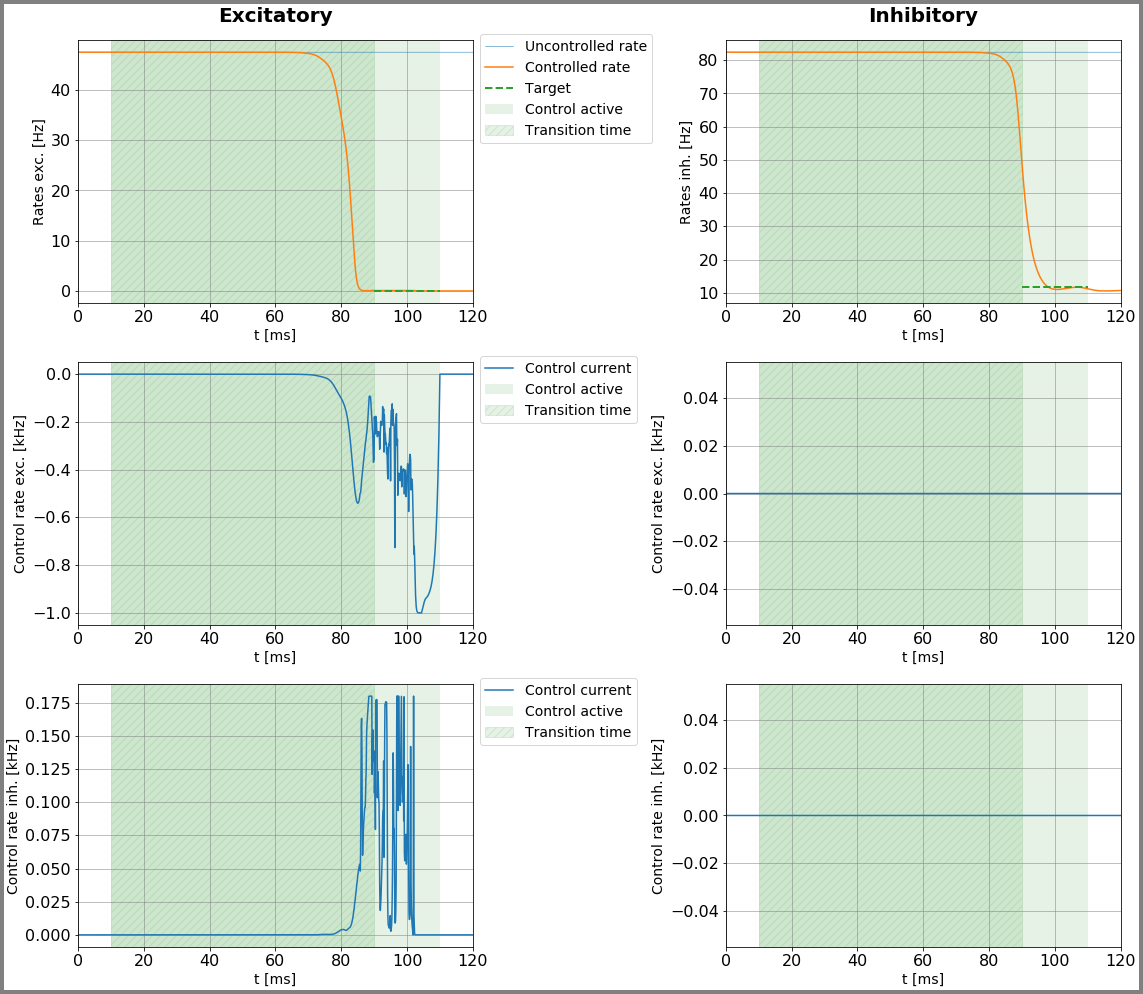

In [15]:
# A.8.a)
case_ind = 8
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

set cost params
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
RUN  1 , total integrated cost =  973.1494953914903
RUN  2 , total integrated cost =  723.7835266402074
RUN  3 , total integrated cost =  505.6419230191318
RUN  4 , total integrated cost =  450.66162414833434
RUN  5 , total integrated cost =  394.1221705582965
RUN  6 , total integrated cost =  371.44744577860035
RUN  7 , total integrated cost =  351.69352081768744
RUN  8 , total integrated cost =  341.1141172895118
RUN  9 , total integrated cost =  332.2077359764999
RUN  10 , total integrated cost =  326.70378610383216
RUN  11 , total integrated cost =  321.4449207744851
RUN  12 , total integrated cost =  318.0532952837113
RUN  13 , total integrated cost =  314.3555010291499
RUN  14 , total integrated cost =  312.19631432253806
RUN  15 , total integrated cost =  309.40676860740507
RUN  16 , total integrated cost =  307.5112010333213
RUN  17 , total integrated cost =  305.452471691

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  1197 , total integrated cost =  231.8191673924916
Improved over  1197  iterations by  98.96939460065327  percent.
Problem in initial value trasfer:  Vmean_exc -57.15494658346237 -57.15274376866155


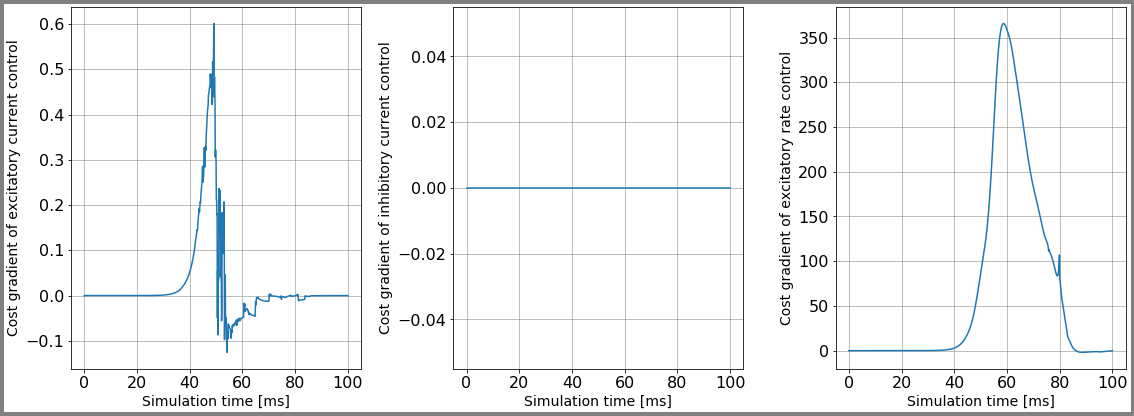

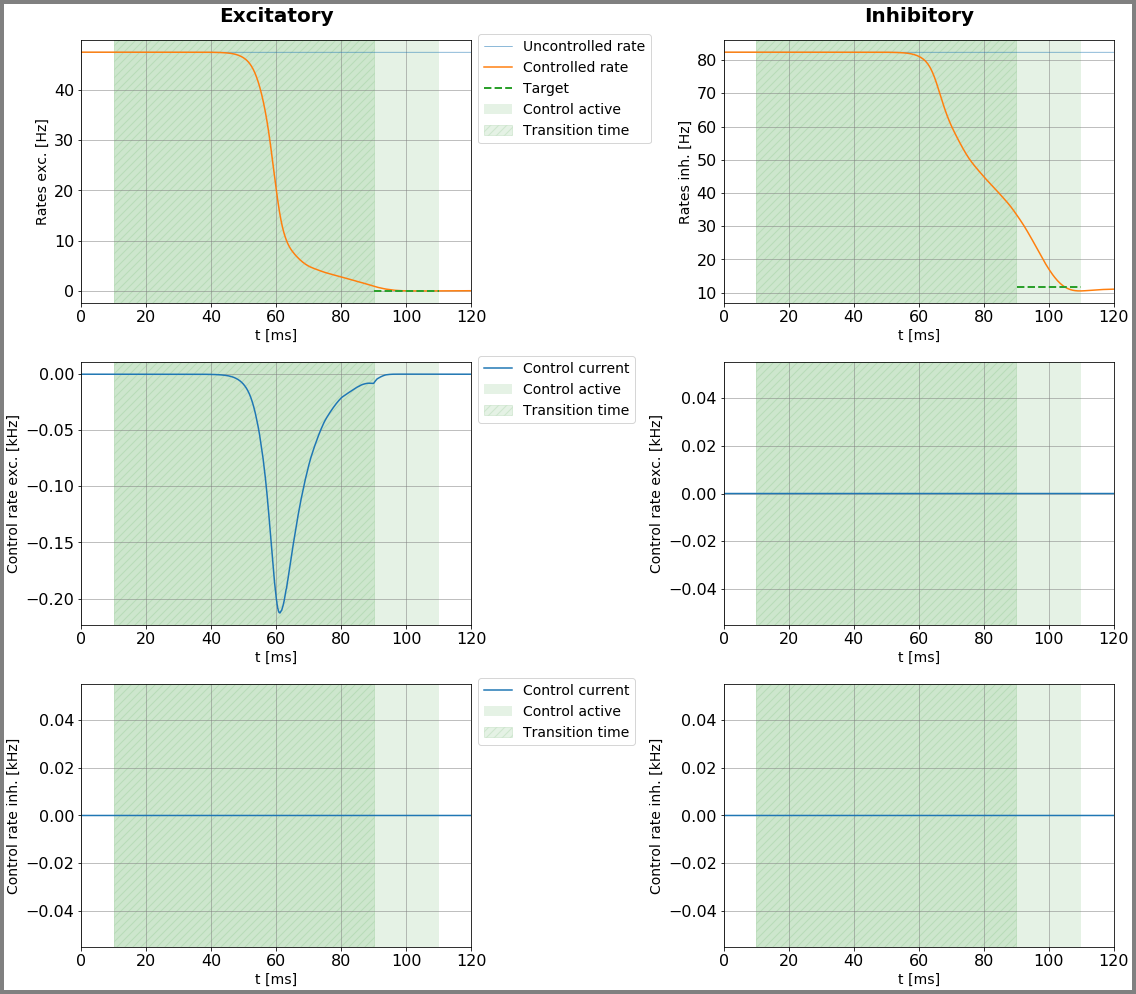

In [16]:
case_ind = 8
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 30.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
    transition_time_ = trans_time ) #separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

## 10

set cost params
control input:  [1, 2] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
RUN  1 , total integrated cost =  17645.071903884807
RUN  2 , total integrated cost =  17645.071611564603
RUN  3 , total integrated cost =  17645.07159126802
RUN  4 , total integrated cost =  17645.071591170505
RUN  5 , total integrated cost =  17645.07159116955
RUN  6 , total integrated cost =  17645.071591169522


ERROR:root:Problem in initial value trasfer


RUN  7 , total integrated cost =  17645.071591169522
Control only changes marginally.
RUN  7 , total integrated cost =  17645.071591169522
Improved over  7  iterations by  21.5547779837824  percent.
Problem in initial value trasfer:  Vmean_exc -56.08376323731158 -56.086770296524435


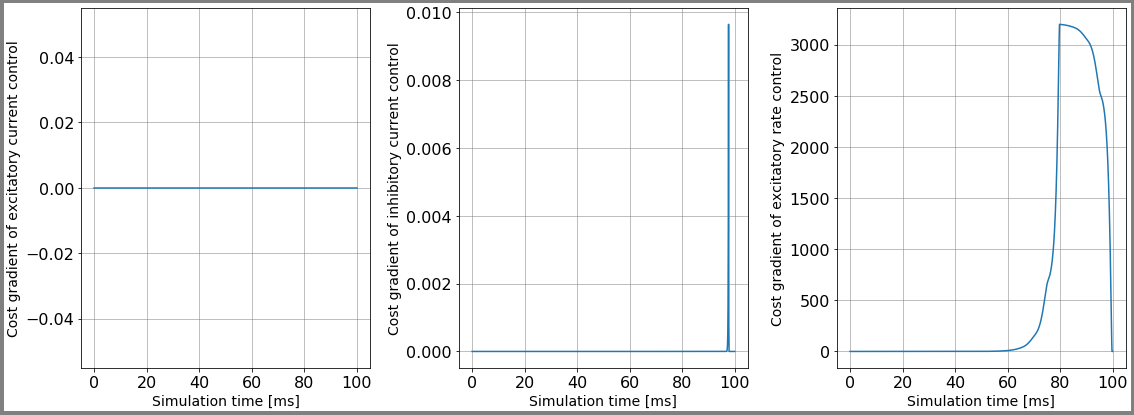

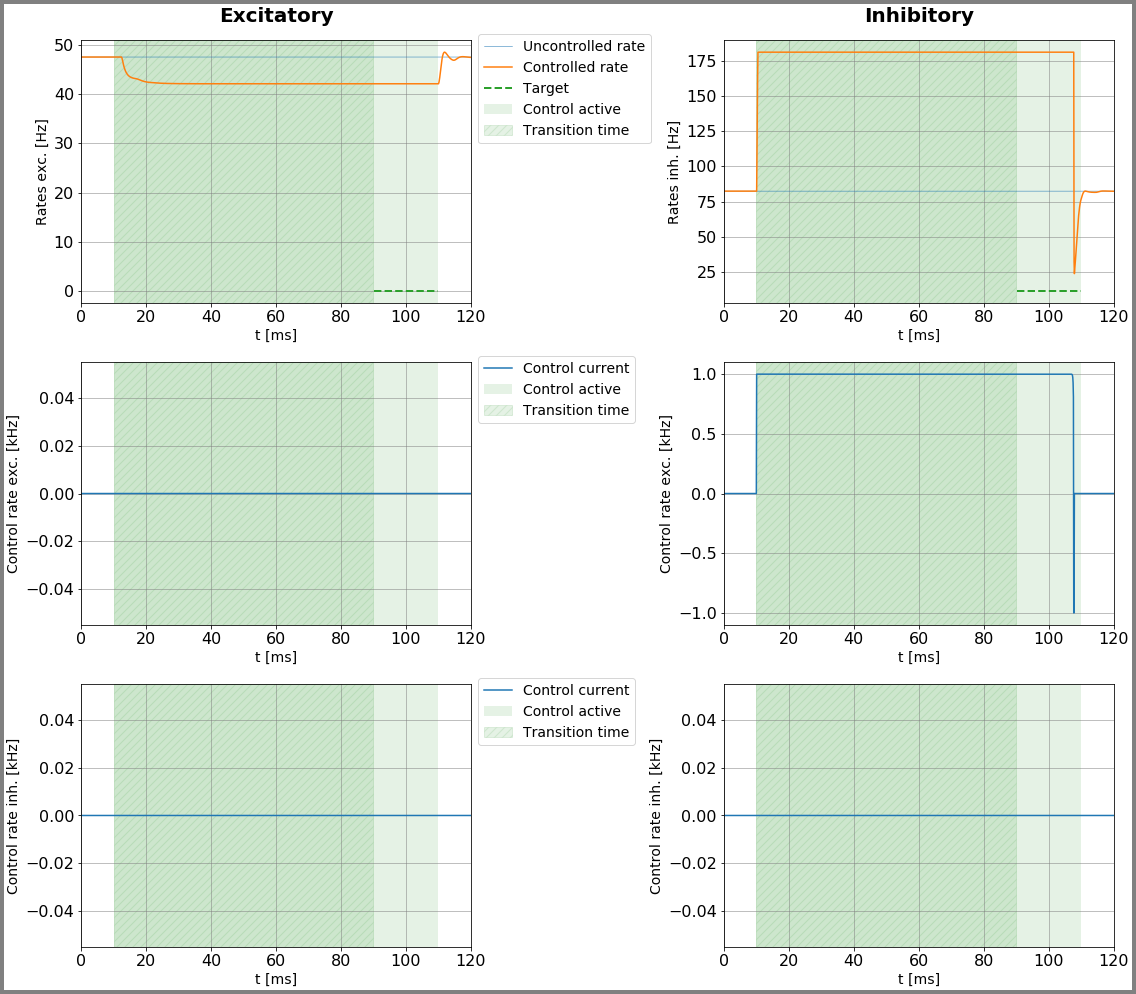

In [17]:
# A.10.a)
case_ind = 10
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

set cost params
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
RUN  1 , total integrated cost =  20713.97859171807
RUN  2 , total integrated cost =  20701.050679324457
RUN  3 , total integrated cost =  20700.7943291295
RUN  4 , total integrated cost =  20700.757542450257
RUN  5 , total integrated cost =  20700.749812818056
RUN  6 , total integrated cost =  20700.742311478356
RUN  7 , total integrated cost =  20700.73844357013
RUN  8 , total integrated cost =  20700.738374051147
RUN  9 , total integrated cost =  20700.737890955934
RUN  10 , total integrated cost =  20700.73655393961
RUN  11 , total integrated cost =  20700.736217142225
RUN  12 , total integrated cost =  20700.7356714599
RUN  13 , total integrated cost =  20700.735610154323
RUN  14 , total integrated cost =  20700.735378946294
RUN  15 , total integrated cost =  20700.735146926905
RUN  16 , total integrated cost =  20700.735095621214
RUN  17 , total integrated cost =  20700.7349

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  24 , total integrated cost =  20700.73435700526
Improved over  24  iterations by  7.970126721010942  percent.
Problem in initial value trasfer:  Vmean_exc -56.13984838129106 -56.141369803786674


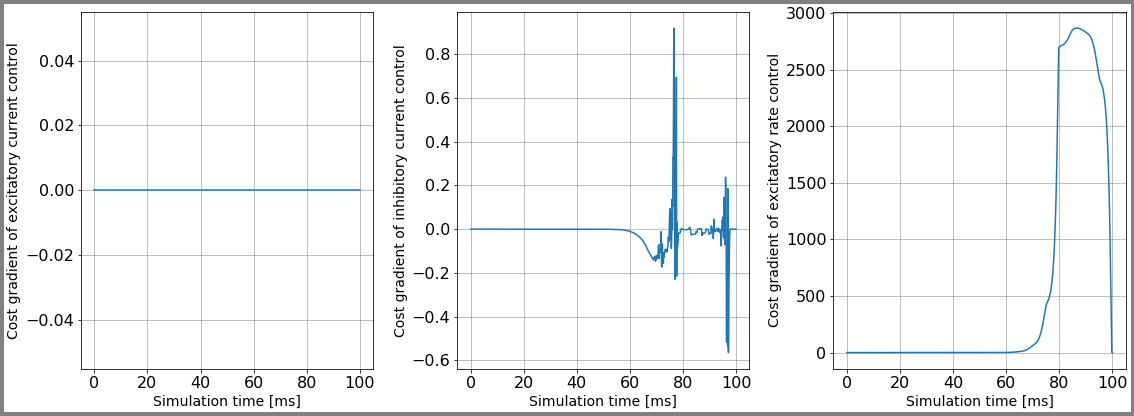

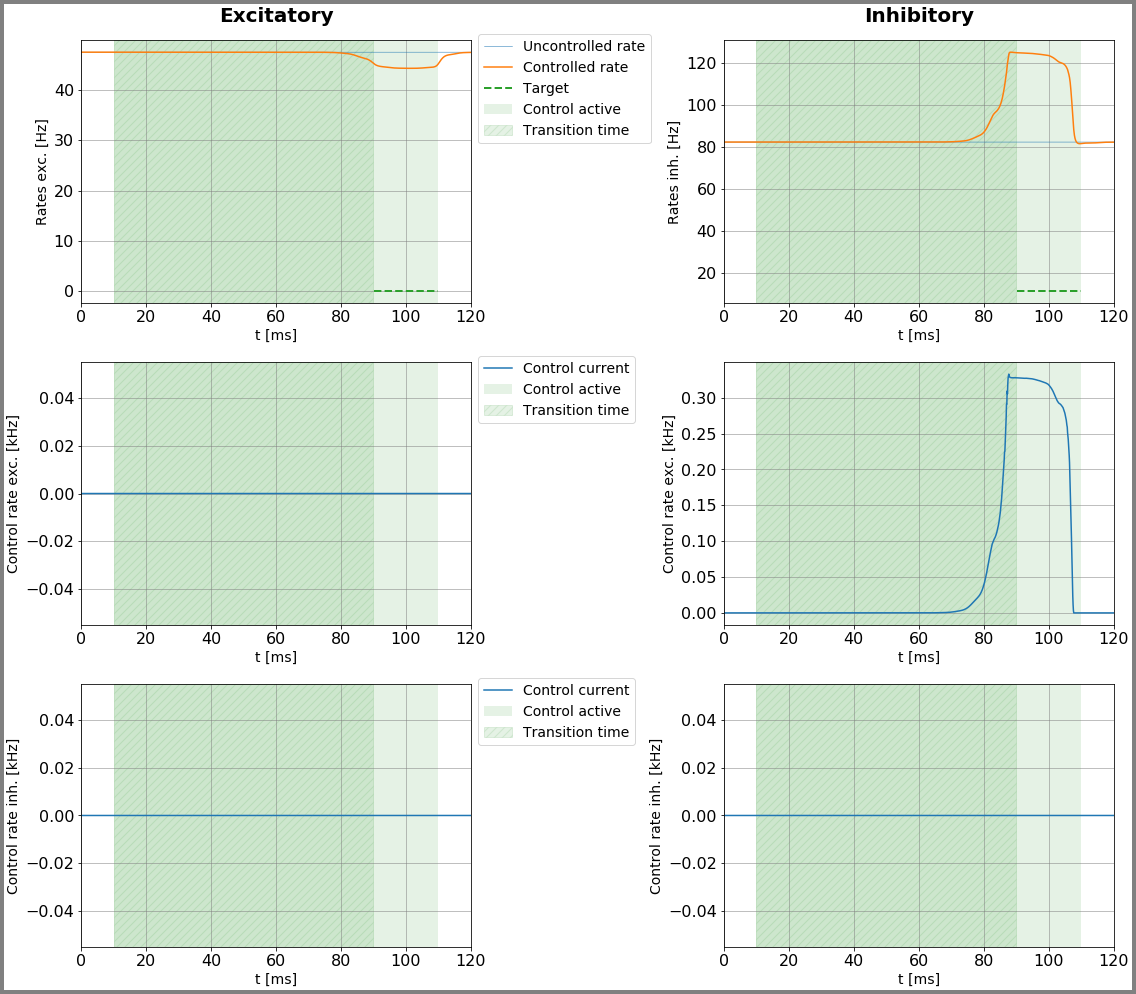

In [18]:
case_ind = 10
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 30.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
    transition_time_ = trans_time ) #separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

## 12

set cost params
control input:  [0, 1, 2] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
RUN  1 , total integrated cost =  0.06696649211560546
RUN  2 , total integrated cost =  0.06677795306452829
RUN  3 , total integrated cost =  0.06650382280064178
RUN  4 , total integrated cost =  0.06572277130532359
RUN  5 , total integrated cost =  0.06554468681689639
RUN  6 , total integrated cost =  0.06539782789036416
RUN  7 , total integrated cost =  0.06531466369663208
RUN  8 , total integrated cost =  0.06522676519469453
RUN  9 , total integrated cost =  0.06514151655564765
RUN  10 , total integrated cost =  0.06504990399960199
RUN  11 , total integrated cost =  0.0648604699952989
RUN  12 , total integrated cost =  0.0647315542886981
RUN  13 , total integrated cost =  0.06442090641366396
RUN  14 , total integrated cost =  0.06425852272578687
RUN  15 , total integrated cost =  0.06422139016890036
RUN  16 , total integrated 

ERROR:root:Problem in initial value trasfer


RUN  5000 , total integrated cost =  0.003163182120730853
RUN  5000 , total integrated cost =  0.003163182120730853
Improved over  5000  iterations by  99.99998593734672  percent.
Problem in initial value trasfer:  Vmean_exc -58.57222626270469 -58.57713577113799


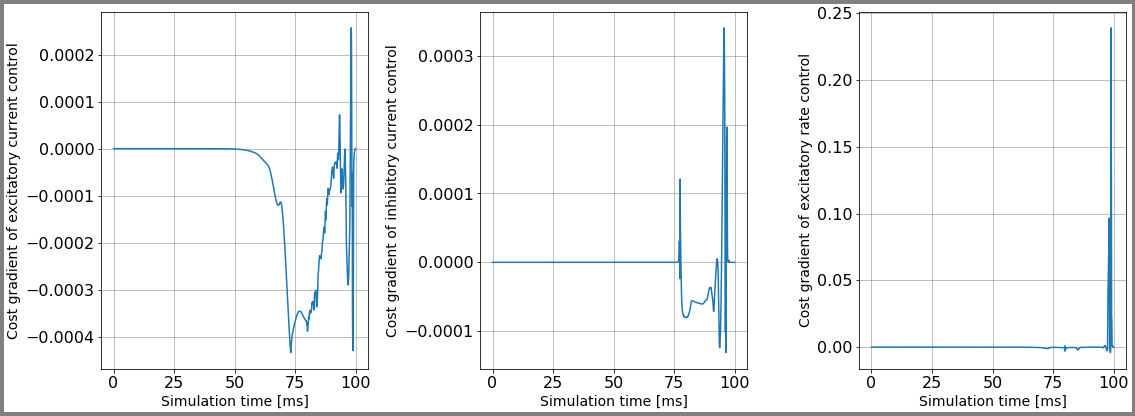

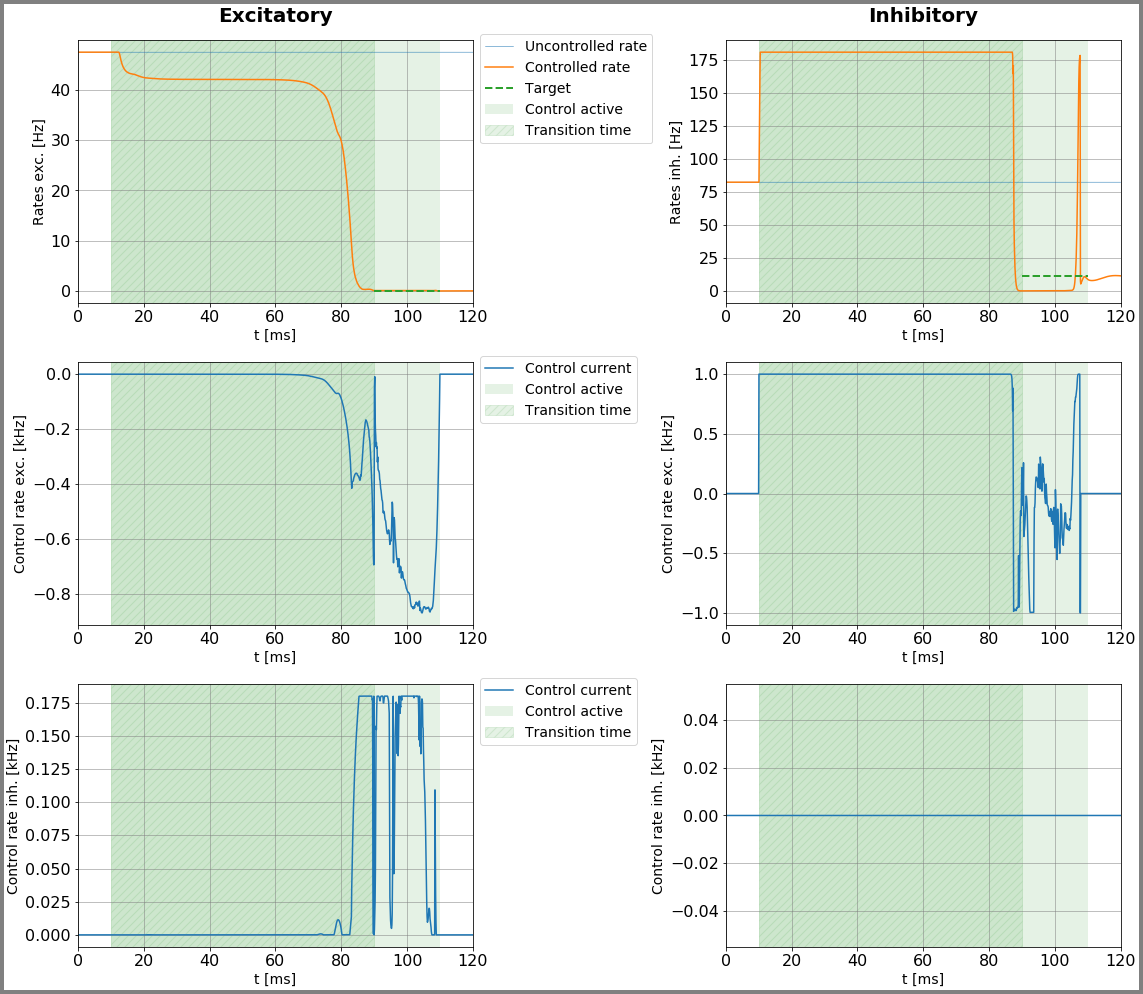

In [19]:
# A.12.a)
case_ind = 12
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

set cost params
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
RUN  1 , total integrated cost =  973.1494953914903
RUN  2 , total integrated cost =  723.7835266402074
RUN  3 , total integrated cost =  505.6419230191318
RUN  4 , total integrated cost =  450.66162414833434
RUN  5 , total integrated cost =  394.1221705582965
RUN  6 , total integrated cost =  371.44744577860035
RUN  7 , total integrated cost =  351.69352081768744
RUN  8 , total integrated cost =  341.1141172895118
RUN  9 , total integrated cost =  332.2077359764999
RUN  10 , total integrated cost =  326.70378610383216
RUN  11 , total integrated cost =  321.4449207744851
RUN  12 , total integrated cost =  318.0532952837113
RUN  13 , total integrated cost =  314.3555010291499
RUN  14 , total integrated cost =  312.19631432253806
RUN  15 , total integrated cost =  309.40676860740507
RUN  16 , total integrated cost =  307.5112010333213
RUN  17 , total integrated cost =  305.452471691

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  1197 , total integrated cost =  231.8191673924916
Improved over  1197  iterations by  98.96939460065327  percent.
Problem in initial value trasfer:  Vmean_exc -57.15494658346237 -57.15274376866155


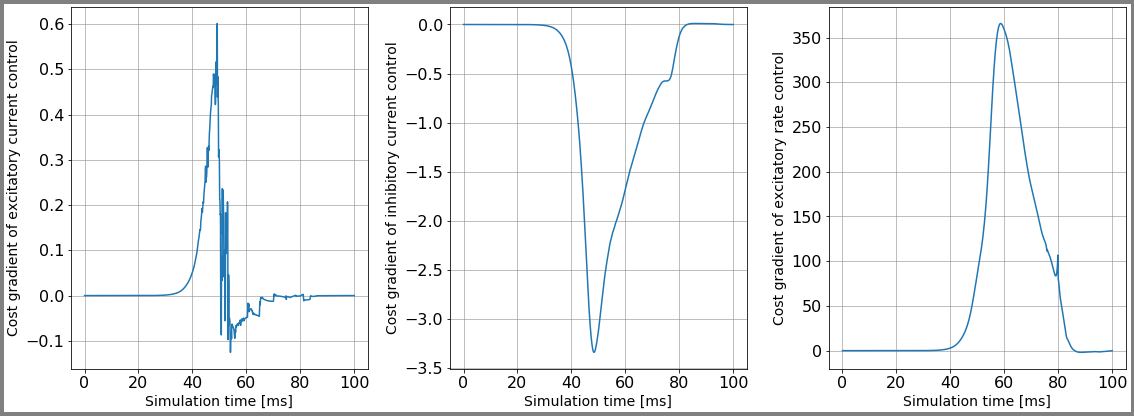

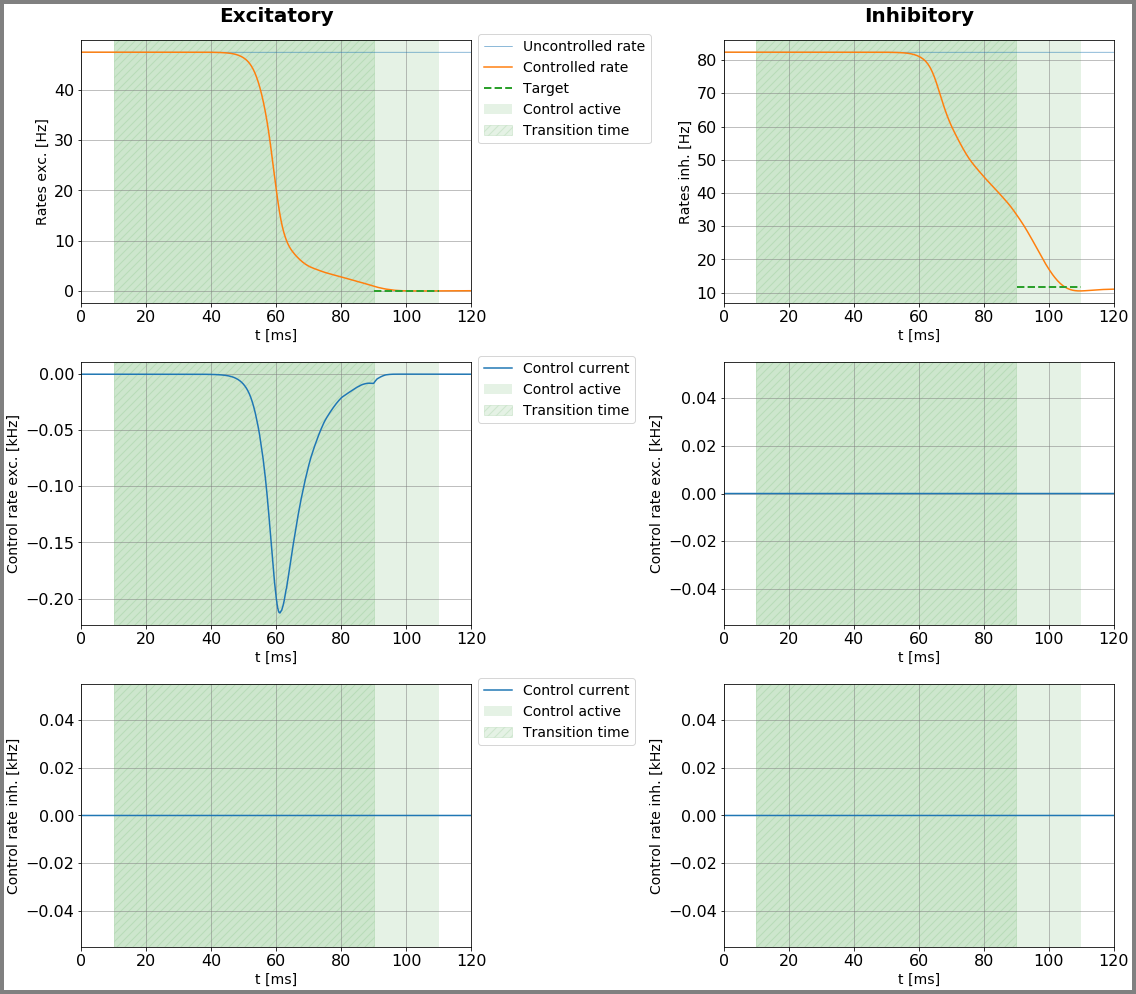

In [20]:
case_ind = 12
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 30.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
    transition_time_ = trans_time ) #separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )